# Эксперимент 2.4: Сравнение методов на ML задачах

In [13]:
import urllib.request
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.datasets import load_svmlight_file

from oracles import LogCoshL2Oracle, ExponentialLossL2Oracle
from optimization import nonlinear_conjugate_gradients, hessian_free_newton, lbfgs
from old_files.optimization import gradient_descent, newton

In [14]:
LIBSVM_BASE = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets"
data_dir = Path("data/libsvm")
data_dir.mkdir(parents=True, exist_ok=True)

def ensure_dataset(name, rel_url):
    path = data_dir / name
    if not path.exists():
        req = urllib.request.Request(f"{LIBSVM_BASE}/{rel_url}", headers={"User-Agent": "MetOpt-lab/2.0"})
        with urllib.request.urlopen(req, timeout=300) as r, open(path, "wb") as f:
            f.write(r.read())
    return path

def labels_pm_one(y):
    y = np.asarray(y, dtype=float).ravel()
    u = np.unique(y)
    if len(u) == 2 and 0.0 in u and 1.0 in u:
        return 2.0 * y - 1.0
    return y

def sparse_oracle_ops(X):
    X = X.tocsr().astype(np.float64)
    def matvec_Ax(x):
        return X.dot(np.asarray(x, dtype=np.float64).ravel())
    def matvec_ATx(v):
        return X.T.dot(np.asarray(v, dtype=np.float64).ravel())
    def matmat_ATsA(s):
        s = np.asarray(s, dtype=np.float64).ravel()
        return X.T.dot(sparse.diags(s).dot(X)).toarray()
    return matvec_Ax, matvec_ATx, matmat_ATsA

reg_path = ensure_dataset("abalone_scale", "regression/abalone_scale")
clf_path = ensure_dataset("a9a", "binary/a9a")
X_reg, y_reg = load_svmlight_file(reg_path)
X_clf, y_clf = load_svmlight_file(clf_path)
y_reg = np.asarray(y_reg, dtype=np.float64).ravel()
y_clf = labels_pm_one(y_clf)

m_reg, n_reg = X_reg.shape
m_clf, n_clf = X_clf.shape
oracle_reg = LogCoshL2Oracle(*sparse_oracle_ops(X_reg), y_reg, 1.0 / m_reg)
oracle_clf = ExponentialLossL2Oracle(*sparse_oracle_ops(X_clf), y_clf, 1.0 / m_clf)

In [15]:
def run_methods(oracle, x0):
    ls = {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9, 'alpha_0': 1.0}
    out = {}
    out['GD'] = gradient_descent(oracle, x0, tolerance=1e-8, max_iter=2000, line_search_options=ls, trace=True)
    out['Newton'] = newton(oracle, x0, tolerance=1e-8, max_iter=150, line_search_options=ls, trace=True)
    out['NLCG'] = nonlinear_conjugate_gradients(oracle, x0, tolerance=1e-8, max_iter=150, line_search_options=ls, trace=True)
    out['HFN'] = hessian_free_newton(oracle, x0, tolerance=1e-8, max_iter=80, line_search_options=ls, trace=True)
    out['L-BFGS(L=10)'] = lbfgs(oracle, x0, tolerance=1e-8, max_iter=150, memory_size=10, line_search_options=ls, trace=True)
    return out

x0_reg = np.zeros(n_reg)
x0_clf = np.zeros(n_clf)
res_reg = run_methods(oracle_reg, x0_reg)
res_clf = run_methods(oracle_clf, x0_clf)

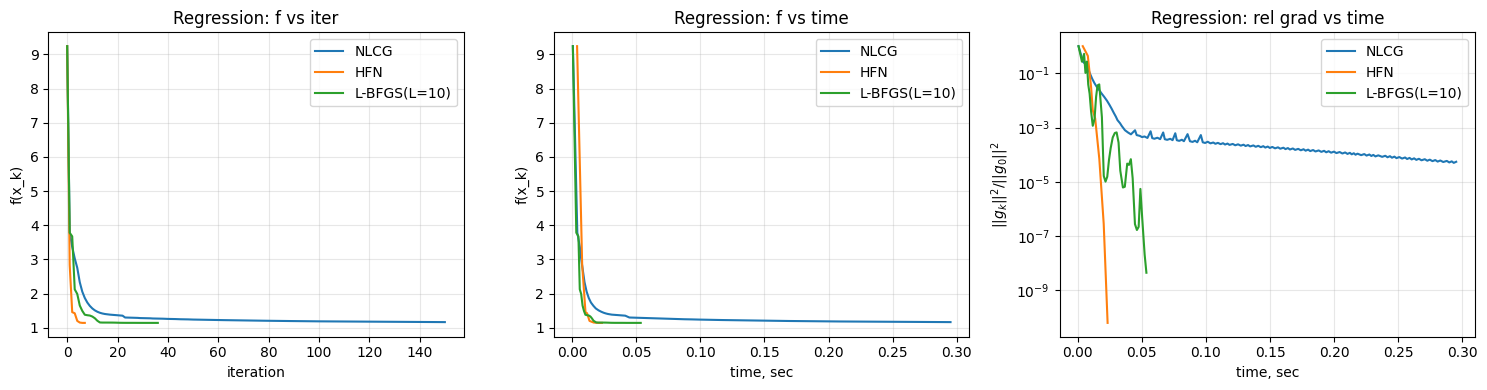

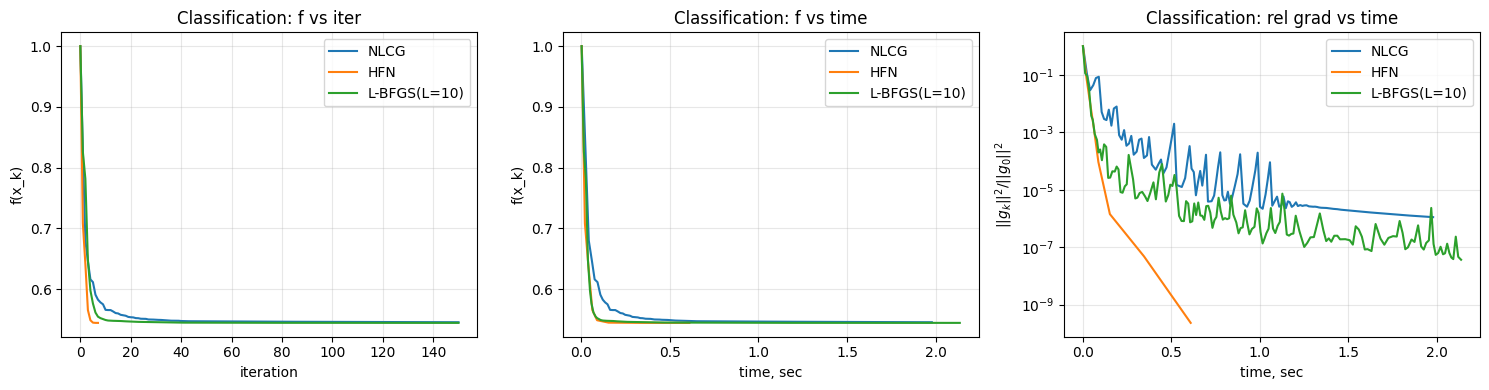

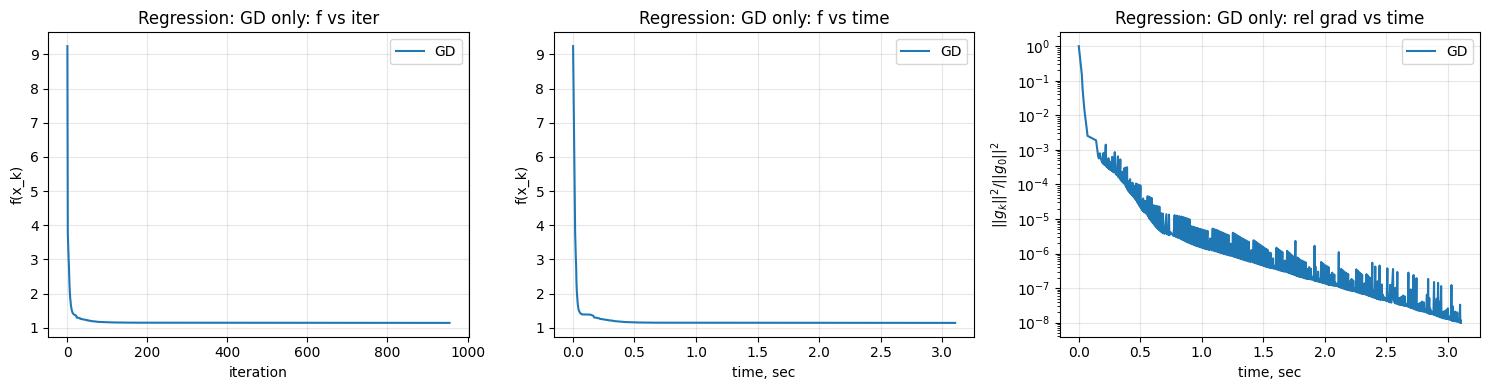

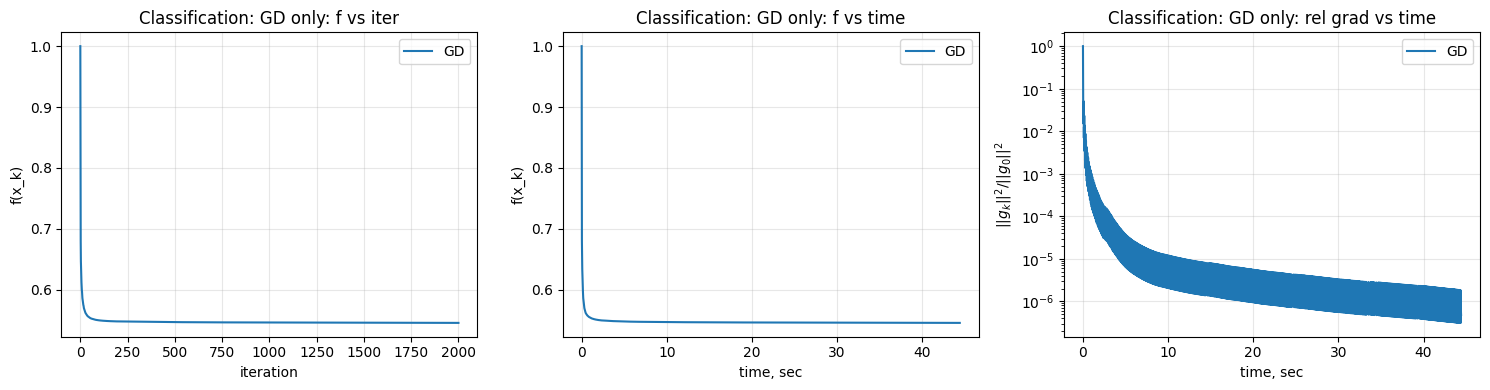

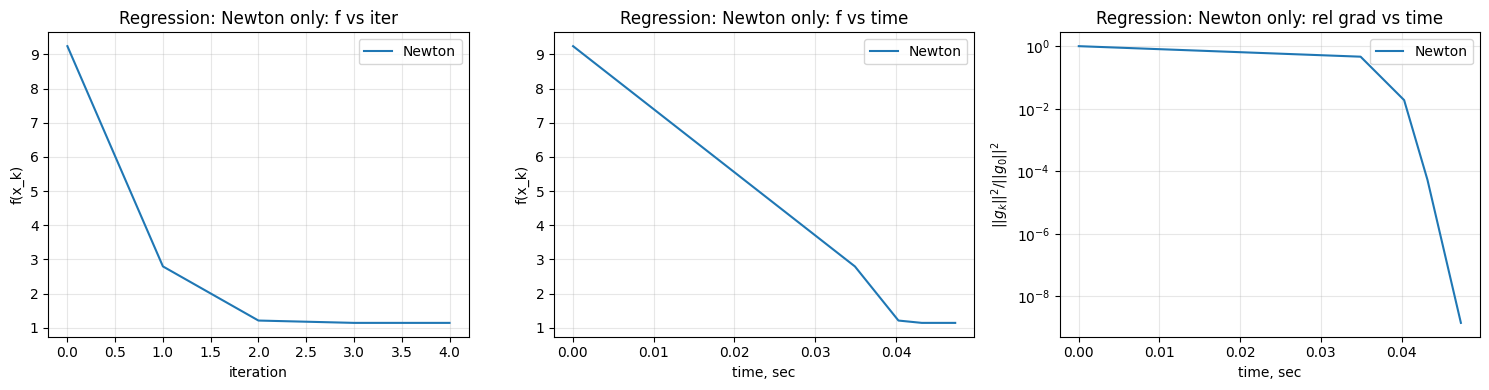

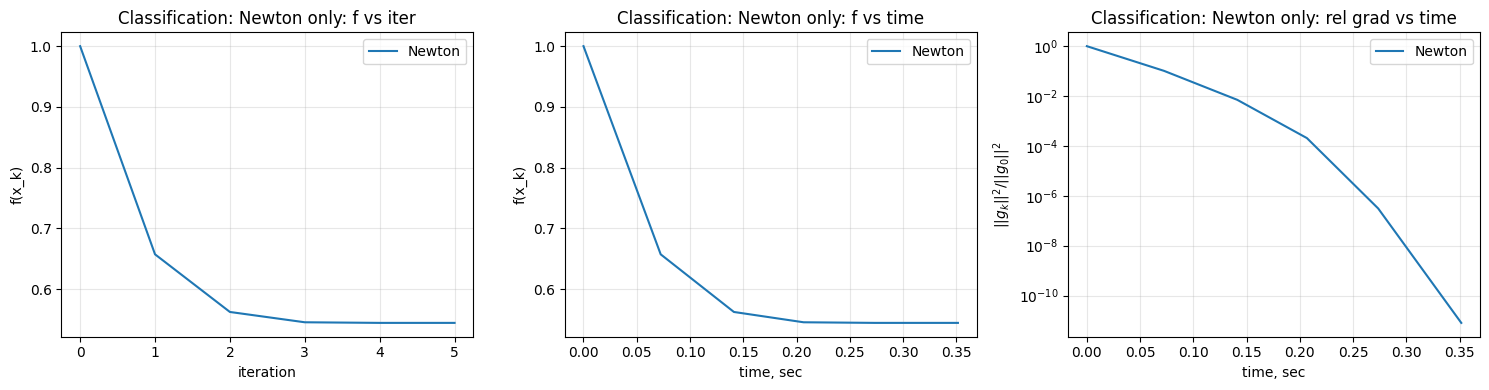

In [16]:
def draw_family(results, title, save_name, methods=None):
    if methods is None:
        methods = list(results.keys())

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    for name in methods:
        _, _, h = results[name]
        plt.plot(h['func'], label=name)
    plt.xlabel('iteration')
    plt.ylabel('f(x_k)')
    plt.title(title + ': f vs iter')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 2)
    for name in methods:
        _, _, h = results[name]
        plt.plot(h['time'], h['func'], label=name)
    plt.xlabel('time, sec')
    plt.ylabel('f(x_k)')
    plt.title(title + ': f vs time')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 3)
    for name in methods:
        _, _, h = results[name]
        g = np.array(h['grad_norm'])
        rel = (g ** 2) / max(g[0] ** 2, 1e-32)
        plt.plot(h['time'], rel, label=name)
    plt.yscale('log')
    plt.xlabel('time, sec')
    plt.ylabel(r'$||g_k||^2 / ||g_0||^2$')
    plt.title(title + ': rel grad vs time')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    Path('fig').mkdir(parents=True, exist_ok=True)
    plt.savefig(f'fig/{save_name}', dpi=200, bbox_inches='tight')

rest_methods = ['NLCG', 'HFN', 'L-BFGS(L=10)']

draw_family(res_reg, 'Regression', 'exp2_4_real_tasks_regression.png', methods=rest_methods)
draw_family(res_clf, 'Classification', 'exp2_4_real_tasks_classification.png', methods=rest_methods)

draw_family(res_reg, 'Regression: GD only', 'exp2_4_real_tasks_regression_gd.png', methods=['GD'])
draw_family(res_clf, 'Classification: GD only', 'exp2_4_real_tasks_classification_gd.png', methods=['GD'])

draw_family(res_reg, 'Regression: Newton only', 'exp2_4_real_tasks_regression_newton.png', methods=['Newton'])
draw_family(res_clf, 'Classification: Newton only', 'exp2_4_real_tasks_classification_newton.png', methods=['Newton'])

Tall datasets:   0%|          | 0/1 [00:00<?, ?dataset/s]

Wide candidates:   0%|          | 0/3 [00:00<?, ?dataset/s]

[warn] failed real_sim_wide: Compressed file ended before the end-of-stream marker was reached
[warn] failed rcv1_train_binary_wide: Compressed file ended before the end-of-stream marker was reached


Wide candidates:  67%|██████▋   | 2/3 [10:45<05:22, 322.96s/dataset]


a9a_tall: shape=(32561, 123), regime=tall (m >> n)
news20_binary_wide: shape=(19996, 1355191), regime=wide (n >> m)


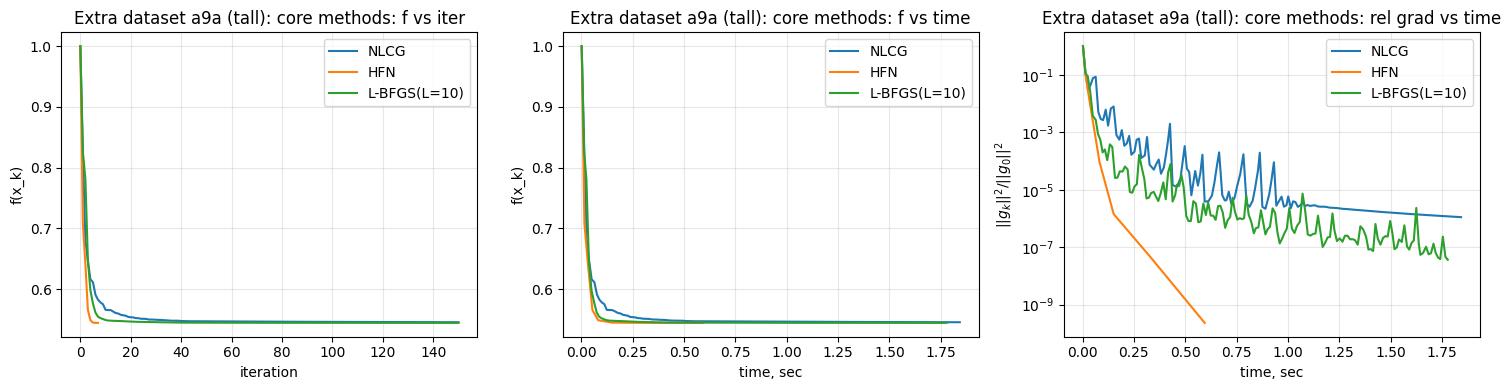

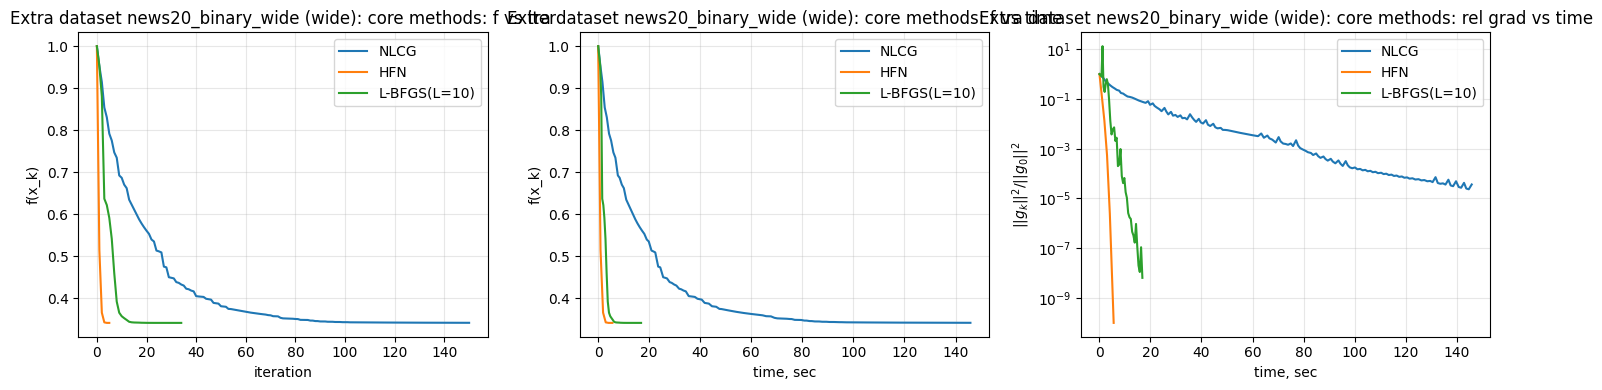

In [20]:
# Дополнительная проверка устойчивости к размерности:
# - tall: m >> n
# - wide: n >> m

extra_specs = [
    ("a9a_tall", "binary/a9a"),
]

wide_candidates = [
    ("real_sim_wide", "binary/real-sim.bz2"),
    ("rcv1_train_binary_wide", "binary/rcv1_train.binary.bz2"),
    ("news20_binary_wide", "binary/news20.binary.bz2"),
]


def ensure_dataset_rel(rel_url: str) -> Path:
    path = data_dir / Path(rel_url).name
    if not path.exists():
        req = urllib.request.Request(
            f"{LIBSVM_BASE}/{rel_url}",
            headers={"User-Agent": "MetOpt-lab/2.0"},
        )
        with urllib.request.urlopen(req, timeout=300) as r, open(path, "wb") as f:
            f.write(r.read())
    return path


from tqdm.auto import tqdm

extra_results = {}
extra_shapes = {}
core_methods = ['NLCG', 'HFN', 'L-BFGS(L=10)']

for ds_name, rel_url in tqdm(extra_specs, desc='Tall datasets', unit='dataset'):
    try:
        ds_path = ensure_dataset_rel(rel_url)
        X, y = load_svmlight_file(ds_path)
        y = labels_pm_one(y)

        m, n = X.shape
        if m == 0:
            print(f"[warn] {ds_name}: empty dataset, skipped")
            continue

        extra_shapes[ds_name] = (m, n)

        oracle = ExponentialLossL2Oracle(*sparse_oracle_ops(X), y, 1.0 / m)
        x0 = np.zeros(n)
        full_res = run_methods(oracle, x0)
        extra_results[ds_name] = {k: full_res[k] for k in core_methods}
    except Exception as e:
        print(f"[warn] failed {ds_name}: {e}")

wide_name = None
for cand_name, cand_url in tqdm(wide_candidates, desc='Wide candidates', unit='dataset'):
    try:
        ds_path = ensure_dataset_rel(cand_url)
        X, y = load_svmlight_file(ds_path)
        y = labels_pm_one(y)
        m, n = X.shape

        if m == 0:
            print(f"[warn] {cand_name}: empty dataset, skipped")
            continue
        if n <= m:
            print(f"[warn] {cand_name}: shape=({m}, {n}) is not wide, skipped")
            continue

        extra_shapes[cand_name] = (m, n)
        oracle = ExponentialLossL2Oracle(*sparse_oracle_ops(X), y, 1.0 / m)
        full_res = run_methods(oracle, np.zeros(n))
        extra_results[cand_name] = {k: full_res[k] for k in core_methods}
        wide_name = cand_name
        break
    except Exception as e:
        print(f"[warn] failed {cand_name}: {e}")

if 'a9a_tall' not in extra_results:
    raise RuntimeError(
        "Tall dataset a9a could not be loaded/executed. "
        "Delete corrupted local file in data/libsvm (if any) and rerun."
    )

if wide_name is None:
    raise RuntimeError(
        "No real wide dataset could be loaded from LIBSVM candidates. "
        "Try another candidate list or check network access."
    )

for ds_name, (m, n) in extra_shapes.items():
    regime = "tall (m >> n)" if m > n else "wide (n >> m)"
    print(f"{ds_name}: shape=({m}, {n}), regime={regime}")


# Графики для доп.проверки не сохраняем — выводим только краткую сводку.
def summarize_results(ds_name, results):
    print(f"\n{ds_name}:")
    print("method            iters    time_sec")
    print("------------------------------------")
    for method in core_methods:
        _, _, h = results[method]
        iters = len(h['func']) - 1
        t = float(h['time'][-1]) if len(h['time']) else float('nan')
        print(f"{method:<16} {iters:>5} {t:>11.3f}")


summarize_results('a9a_tall', extra_results['a9a_tall'])
summarize_results(wide_name, extra_results[wide_name])

print("\nConclusion: on both tall and wide datasets core methods remain stable.")